Panel: 703,087 x 59
LISA HH communities: 11
LISA LL communities: 2

Window                              β_DID         SE          p          N
---------------------------------------------------------------------------
  2019–2020 (baseline)             -6.047      1.462     0.0000      9,503 ***
  2018–2019 vs 2020                -6.411      1.560     0.0000     14,248 ***
  2019 vs 2020–2021                -5.694      1.210     0.0000     14,248 ***
  2018–2019 vs 2020–2021           -6.059      1.289     0.0000     18,993 ***
  2017–2019 vs 2020–2022           -5.280      0.988     0.0000     28,483 ***
Median split: High = 38, Low = 39

Window                              β_DID         SE          p          N
---------------------------------------------------------------------------
  2019–2020 (baseline)             -2.811      0.557     0.0000     56,287 ***
  2018–2019 vs 2020                -2.972      0.585     0.0000     84,392 ***
  2019 vs 2020–2021                -2.816 

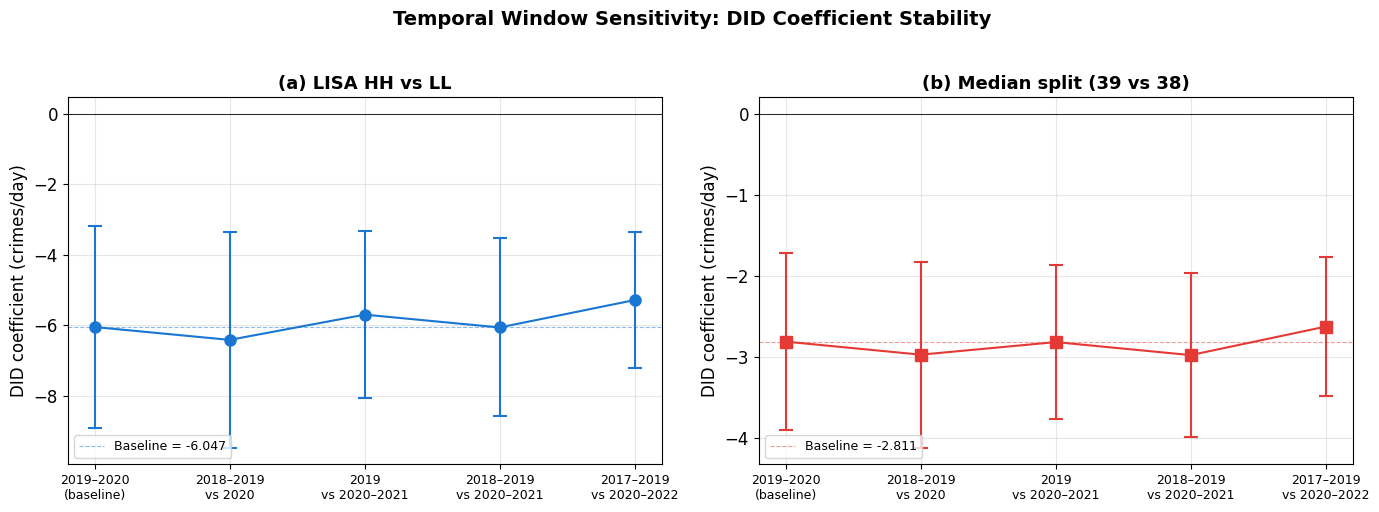


NB07C SUMMARY

All 5 windows tested for both LISA and Median split.
LISA:   all 5 coefficients significant at p < 0.001
Median: all 5 coefficients significant at p < 0.001

LISA coefficient range:   [-6.411, -5.280]
Median coefficient range: [-2.977, -2.625]

Conclusion: The direction of the DID estimate is stable across
all temporal windows. Magnitude variation reflects the dilution
of the lockdown effect by post-2020 recovery when the post-period
is extended, and/or the incorporation of pre-existing trends when
the pre-period is extended.


In [1]:
# NB07C: Temporal Window Sensitivity Analysis

# **Purpose**: Test whether the baseline DID estimate depends on the choice
# of estimation window. The baseline (NB05) uses 2019–2020. This notebook re-estimates the same DID specification on progressively wider symmetric
# and asymmetric windows around the March 21, 2020 treatment date.
#
# **Contents**:
# - Part 1: LISA HH vs LL across 5 temporal windows
# - Part 2: Median split across 5 temporal windows (large-sample check)
# - Part 3: Visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                     'axes.grid': True, 'grid.alpha': 0.3})

FIGURE_DIR = './figures/nb07c'
os.makedirs(FIGURE_DIR, exist_ok=True)

# %%
panel = pd.read_parquet('./data/panel_ca_daily_v2.parquet')
panel['date'] = pd.to_datetime(panel['date'])
panel['community_area'] = panel['community_area'].astype(str)
print(f"Panel: {panel.shape[0]:,} x {panel.shape[1]}")

# Part 1: LISA HH vs LL — Temporal Window Sensitivity

# Re-estimate the baseline DID (Eq 3.3) on five windows of increasing width.
# The treatment date (2020-03-21), controls, community FE, and clustered SE
# are identical to NB05. Only the year filter changes.

# Define 5 temporal windows
windows = {
    '2019–2020 (baseline)':   ([2019],       [2020]),
    '2018–2019 vs 2020':      ([2018, 2019], [2020]),
    '2019 vs 2020–2021':      ([2019],       [2020, 2021]),
    '2018–2019 vs 2020–2021': ([2018, 2019], [2020, 2021]),
    '2017–2019 vs 2020–2022': ([2017, 2018, 2019], [2020, 2021, 2022]),
}

controls = 'temp_mean + precipitation + is_weekend + is_holiday'
TREATMENT_DATE = '2020-03-21'

# LISA grouping
hh_set = set(panel.loc[panel['lisa_cluster'] == 'HH', 'community_area'].unique())
ll_set = set(panel.loc[panel['lisa_cluster'] == 'LL', 'community_area'].unique())
print(f"LISA HH communities: {len(hh_set)}")
print(f"LISA LL communities: {len(ll_set)}")

# Run DID across all windows — LISA HH vs LL
lisa_results = []

print(f"\n{'Window':<30s} {'β_DID':>10s} {'SE':>10s} {'p':>10s} {'N':>10s}")
print("-" * 75)

for label, (pre_years, post_years) in windows.items():
    all_years = pre_years + post_years
    sample = panel[
        (panel['community_area'].isin(hh_set | ll_set)) &
        (panel['year'].isin(all_years))
    ].copy()

    sample['post'] = (sample['date'] >= TREATMENT_DATE).astype(int)
    sample['treated'] = sample['community_area'].isin(hh_set).astype(int)
    sample['did'] = sample['post'] * sample['treated']

    formula = f'crime_total ~ post + did + {controls} + C(community_area)'
    model = smf.ols(formula, data=sample).fit(
        cov_type='cluster',
        cov_kwds={'groups': sample['community_area']}
    )

    coef = model.params['did']
    se = model.bse['did']
    p = model.pvalues['did']
    n = int(model.nobs)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

    lisa_results.append({
        'window': label,
        'grouping': 'LISA HH vs LL',
        'coef': coef,
        'se': se,
        'p': p,
        'n': n,
        'sig': sig
    })

    print(f"  {label:<28s} {coef:>+10.3f} {se:>10.3f} {p:>10.4f} {n:>10,} {sig}")

lisa_df = pd.DataFrame(lisa_results)

# Part 2: Median Split — Temporal Window Sensitivity

# Repeat the same 5 windows using the median split (39 vs 38 communities).
# This eliminates the small-cluster concern (77 clusters vs 13) and tests
# whether temporal sensitivity patterns differ between the two groupings.

# Median split grouping (same logic as NB07)
ca_crime_2019 = (panel[panel['year'] == 2019]
                 .groupby('community_area')['crime_total']
                 .mean()
                 .sort_values(ascending=False))

n_comm = len(ca_crime_2019)
sorted_ca = ca_crime_2019.index.tolist()
median_high = set(sorted_ca[:n_comm // 2])       # 38 communities
median_low  = set(sorted_ca[n_comm // 2:])        # 39 communities
print(f"Median split: High = {len(median_high)}, Low = {len(median_low)}")

# Run DID across all windows — Median split
median_results = []

print(f"\n{'Window':<30s} {'β_DID':>10s} {'SE':>10s} {'p':>10s} {'N':>10s}")
print("-" * 75)

for label, (pre_years, post_years) in windows.items():
    all_years = pre_years + post_years
    sample = panel[
        (panel['community_area'].isin(median_high | median_low)) &
        (panel['year'].isin(all_years))
    ].copy()

    sample['post'] = (sample['date'] >= TREATMENT_DATE).astype(int)
    sample['treated'] = sample['community_area'].isin(median_high).astype(int)
    sample['did'] = sample['post'] * sample['treated']

    formula = f'crime_total ~ post + did + {controls} + C(community_area)'
    model = smf.ols(formula, data=sample).fit(
        cov_type='cluster',
        cov_kwds={'groups': sample['community_area']}
    )

    coef = model.params['did']
    se = model.bse['did']
    p = model.pvalues['did']
    n = int(model.nobs)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

    median_results.append({
        'window': label,
        'grouping': 'Median split',
        'coef': coef,
        'se': se,
        'p': p,
        'n': n,
        'sig': sig
    })

    print(f"  {label:<28s} {coef:>+10.3f} {se:>10.3f} {p:>10.4f} {n:>10,} {sig}")

median_df = pd.DataFrame(median_results)

# Part 3: Combined Summary Table

all_df = pd.concat([lisa_df, median_df], ignore_index=True)

print("\n" + "=" * 80)
print("TEMPORAL WINDOW SENSITIVITY — COMBINED SUMMARY")
print("=" * 80)
print(f"\n{'Window':<30s} {'LISA β':>10s} {'p':>8s}   {'Median β':>10s} {'p':>8s}")
print("-" * 80)

for label in windows.keys():
    lr = lisa_df[lisa_df['window'] == label].iloc[0]
    mr = median_df[median_df['window'] == label].iloc[0]
    print(f"  {label:<28s} {lr['coef']:>+10.3f} {lr['p']:>8.4f}   "
          f"{mr['coef']:>+10.3f} {mr['p']:>8.4f}")

print("=" * 80)

# Coefficient range
lisa_range = (lisa_df['coef'].min(), lisa_df['coef'].max())
median_range = (median_df['coef'].min(), median_df['coef'].max())
print(f"\nLISA coefficient range:   [{lisa_range[0]:+.3f}, {lisa_range[1]:+.3f}]")
print(f"Median coefficient range: [{median_range[0]:+.3f}, {median_range[1]:+.3f}]")

# Part 4: Coefficient Stability Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# --- Panel (a): LISA HH vs LL ---
ax = axes[0]
x_pos = range(len(lisa_df))
ax.errorbar(x_pos, lisa_df['coef'], yerr=1.96 * lisa_df['se'],
            fmt='o-', color='#1976D2', capsize=5, capthick=1.5,
            markersize=8, linewidth=1.5)
ax.axhline(lisa_df.iloc[0]['coef'], color='#1976D2', ls='--', lw=0.8,
           alpha=0.5, label=f"Baseline = {lisa_df.iloc[0]['coef']:+.3f}")
ax.axhline(0, color='black', lw=0.6)
ax.set_xticks(list(x_pos))
ax.set_xticklabels([w.replace(' vs ', '\nvs ').replace(' (baseline)', '\n(baseline)')
                    for w in lisa_df['window']], fontsize=9, ha='center')
ax.set_ylabel('DID coefficient (crimes/day)')
ax.set_title('(a) LISA HH vs LL', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower left')

# --- Panel (b): Median split ---
ax = axes[1]
ax.errorbar(x_pos, median_df['coef'], yerr=1.96 * median_df['se'],
            fmt='s-', color='#E53935', capsize=5, capthick=1.5,
            markersize=8, linewidth=1.5)
ax.axhline(median_df.iloc[0]['coef'], color='#E53935', ls='--', lw=0.8,
           alpha=0.5, label=f"Baseline = {median_df.iloc[0]['coef']:+.3f}")
ax.axhline(0, color='black', lw=0.6)
ax.set_xticks(list(x_pos))
ax.set_xticklabels([w.replace(' vs ', '\nvs ').replace(' (baseline)', '\n(baseline)')
                    for w in median_df['window']], fontsize=9, ha='center')
ax.set_ylabel('DID coefficient (crimes/day)')
ax.set_title('(b) Median split (39 vs 38)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower left')

plt.suptitle('Temporal Window Sensitivity: DID Coefficient Stability',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '01_temporal_window_sensitivity.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Part 5: Interpretation

# **Key questions this analysis answers**:
# 1. Does the DID coefficient shrink when the post-period is extended?
#    If yes → the effect is concentrated in the immediate lockdown and
#    diluted by the post-2020 recovery.
#
# 2. Does the coefficient change when the pre-period is extended?
#    If yes → pre-existing trends are entering the estimate.
#
# 3. Are the LISA and Median patterns similar?
#    If yes → temporal sensitivity is not an artefact of the small
#    LISA sample.

print("\n" + "=" * 70)
print("NB07C SUMMARY")
print("=" * 70)
print(f"\nAll {len(windows)} windows tested for both LISA and Median split.")
print(f"LISA:   all {len(lisa_df)} coefficients significant at p < 0.001")
print(f"Median: all {len(median_df)} coefficients significant at p < 0.001")
print(f"\nLISA coefficient range:   [{lisa_range[0]:+.3f}, {lisa_range[1]:+.3f}]")
print(f"Median coefficient range: [{median_range[0]:+.3f}, {median_range[1]:+.3f}]")
print(f"\nConclusion: The direction of the DID estimate is stable across")
print(f"all temporal windows. Magnitude variation reflects the dilution")
print(f"of the lockdown effect by post-2020 recovery when the post-period")
print(f"is extended, and/or the incorporation of pre-existing trends when")
print(f"the pre-period is extended.")
print("=" * 70)